In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## LOAD DATA

In [3]:
from google.colab import files

print("Upload the .csv file")
uploaded = files.upload()
df = pd.read_csv('adult income dataset.csv')

df.head(10)

Upload the .csv file


Saving adult income dataset.csv to adult income dataset.csv


,Age,Workclass,Final Weight,Education,Education Number of Years,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


# DATA DESCRIPTION

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        48842 non-null  int64 
 1   Workclass                  48842 non-null  object
 2   Final Weight               48842 non-null  int64 
 3   Education                  48842 non-null  object
 4   Education Number of Years  48842 non-null  int64 
 5   Marital-status             48842 non-null  object
 6   Occupation                 48842 non-null  object
 7   Relationship               48842 non-null  object
 8   Race                       48842 non-null  object
 9   Sex                        48842 non-null  object
 10  Capital-gain               48842 non-null  int64 
 11  Capital-loss               48842 non-null  int64 
 12  Hours-per-week             48842 non-null  int64 
 13  Native-country             48842 non-null  object
 14  target

# DATASET ANALYSIS

In [5]:
# how many features?
print(f"There are {df.shape[1]} features in the dataset")
print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- Column Names ---")
print(df.columns.tolist())
print("\n--- Statistical Summary (Numerical features) ---")
print(df.describe())
print("\n--- Dataset Info (Dtypes, Memory) ---")
df.info()

print("\n--- Checking for Null/NaN values ---")
print(df.isnull().sum())

print("\n--- Columns with any null values ---")
print(df.isnull().any())

print("\n--- Unique values in target column 'target' ---")
print(df['target'].unique())
# how many data points?
print(f"There are {len(df)} data points.")
# what kind of features?
print(set(df.dtypes))


There are 15 features in the dataset

--- Dataset Shape ---
Rows: 48842, Columns: 15

--- Column Names ---
['Age', 'Workclass', 'Final Weight', 'Education', 'Education Number of Years', 'Marital-status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital-gain', 'Capital-loss', 'Hours-per-week', 'Native-country', 'target']

--- Statistical Summary (Numerical features) ---
                Age  Final Weight  Education Number of Years  Capital-gain  \
count  48842.000000  4.884200e+04               48842.000000  48842.000000   
mean      38.643585  1.896641e+05                  10.078089   1079.067626   
std       13.710510  1.056040e+05                   2.570973   7452.019058   
min       17.000000  1.228500e+04                   1.000000      0.000000   
25%       28.000000  1.175505e+05                   9.000000      0.000000   
50%       37.000000  1.781445e+05                  10.000000      0.000000   
75%       48.000000  2.376420e+05                  12.000000      0.000000   

# TARGET DISTRIBUTION

In [6]:
# equal number of instances?
instance_counts=df['target'].value_counts()
print(instance_counts)

target
<=50K    37155
>50K     11687
Name: count, dtype: int64


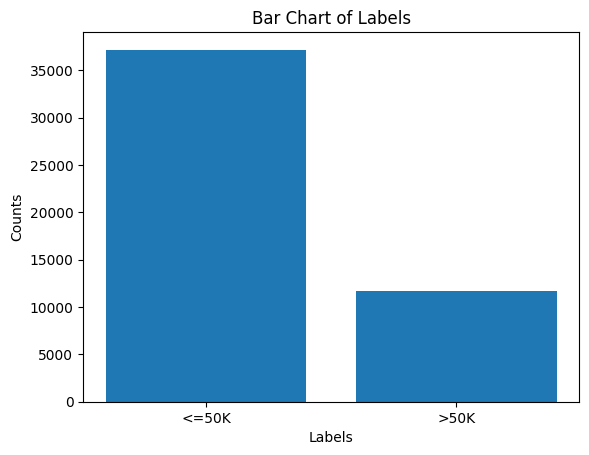

In [7]:
instance_counts = df['target'].value_counts()
labels = instance_counts.index.tolist()
values = instance_counts.values.tolist()

plt.bar(labels, values)
plt.xlabel("Labels")
plt.ylabel("Counts")
plt.title("Bar Chart of Labels")
plt.show()

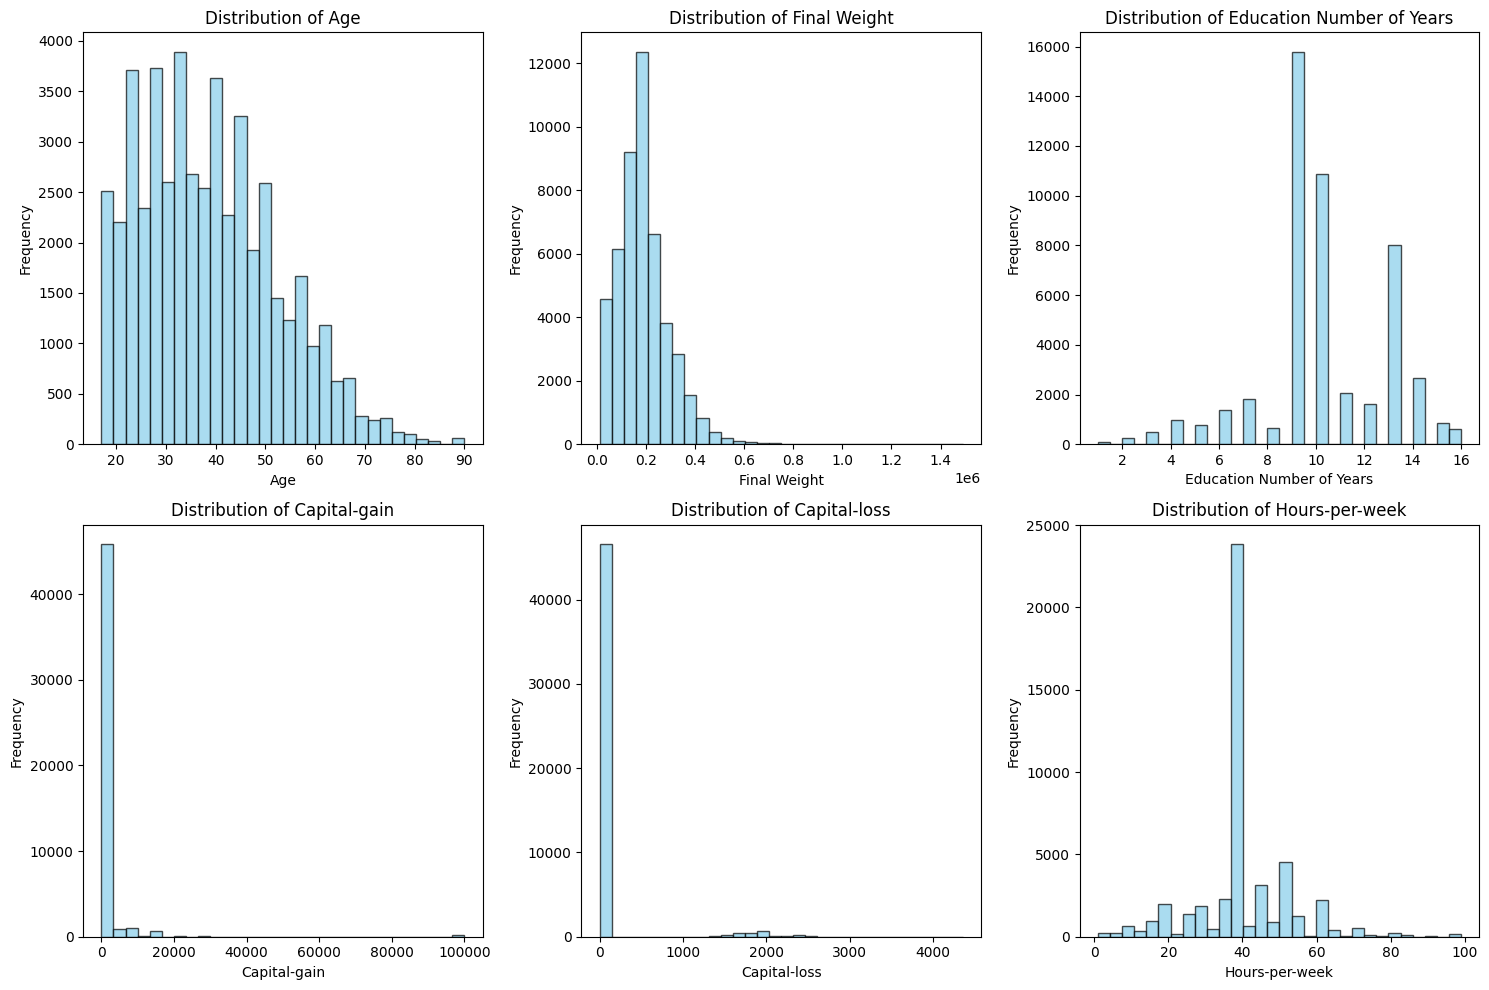

In [8]:
# Numerial Features Distribution
numerical_cols = ['Age', 'Final Weight', 'Education Number of Years',
                  'Capital-gain', 'Capital-loss', 'Hours-per-week'] # Taken Manually

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3327/3617631580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3327/3617631580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3327/3617631580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3327/3617631580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

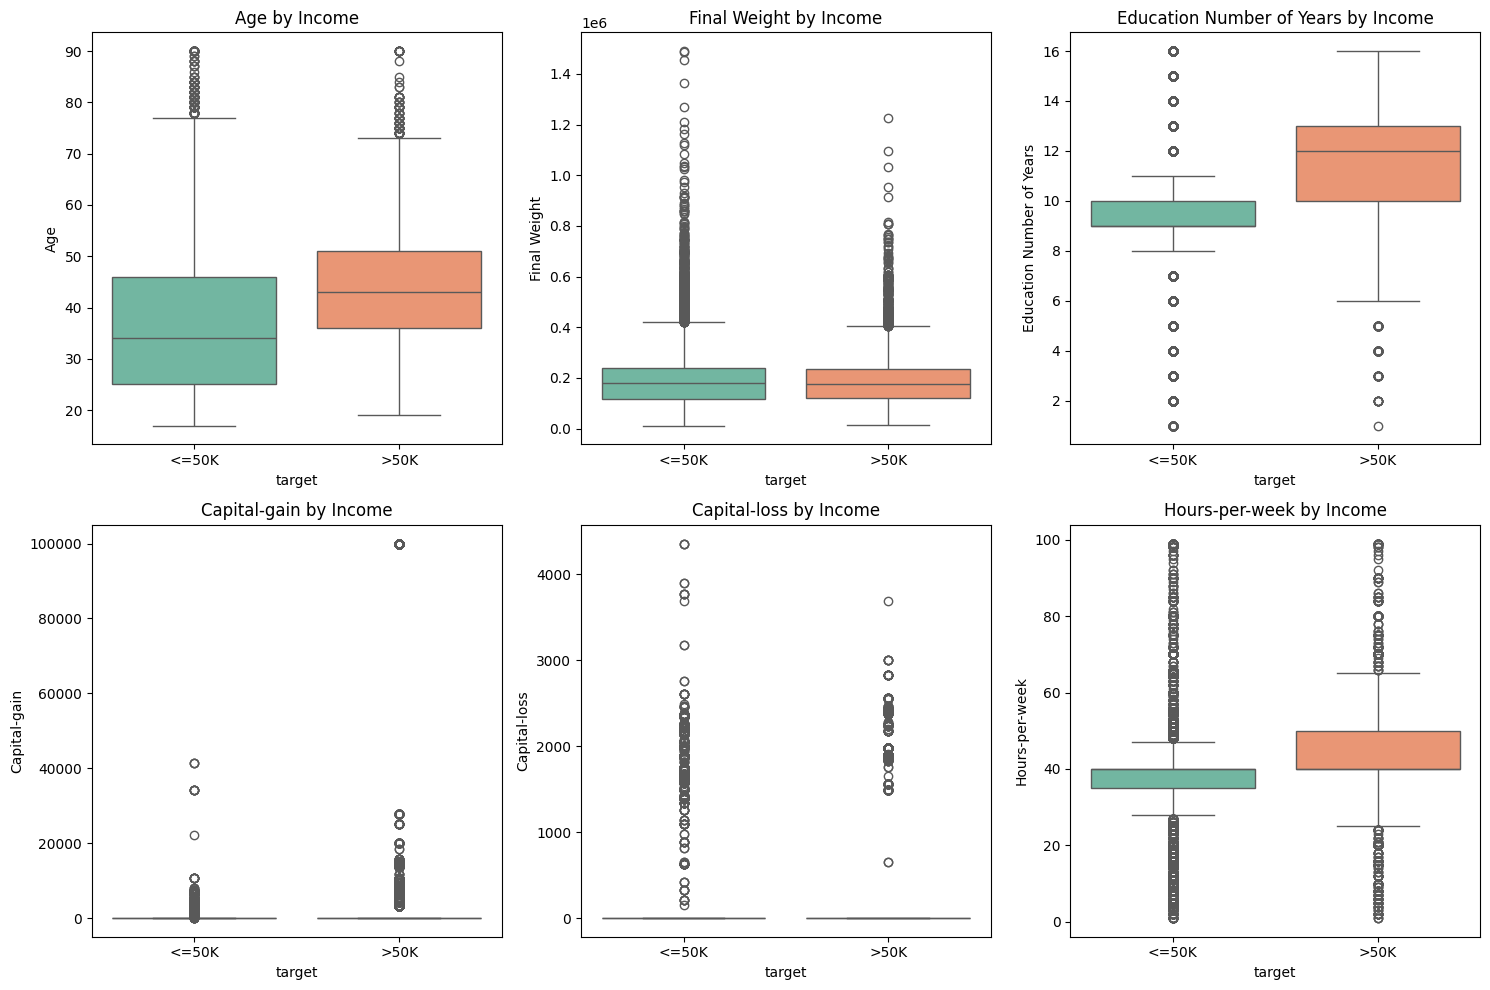

In [9]:
# Box Plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Income', fontsize=12)

plt.tight_layout()
plt.show()

# CORRELATION

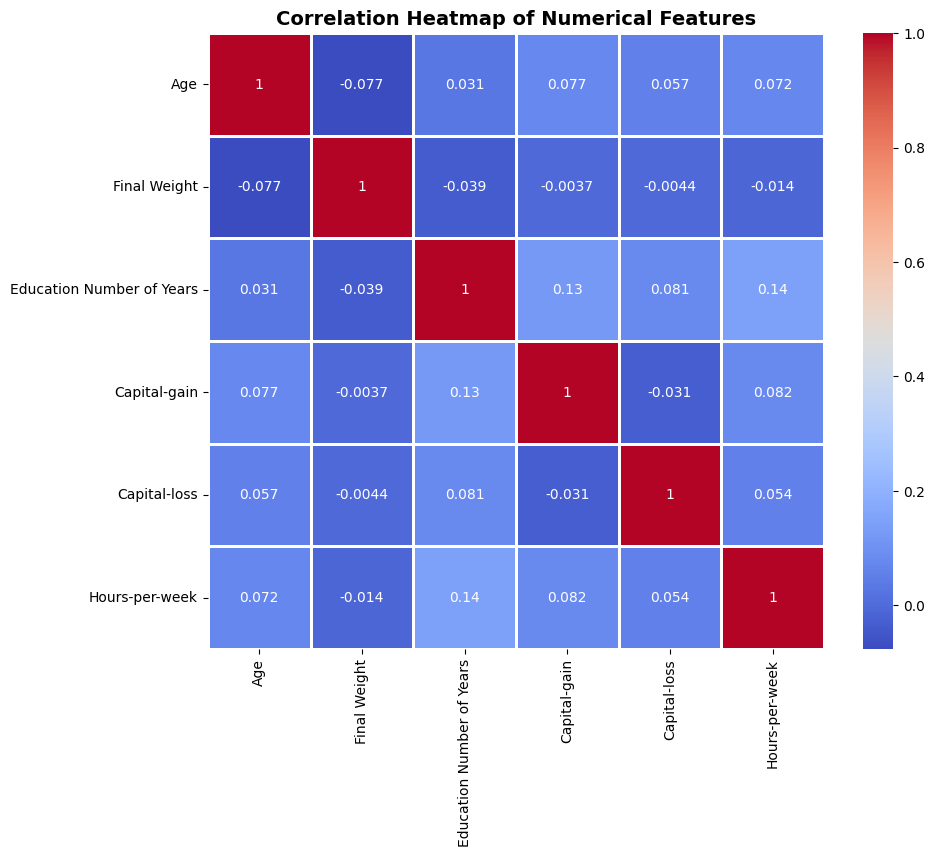

In [10]:
plt.figure(figsize=(10,8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            square=True, linewidths=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

<Axes: xlabel='Education Number of Years', ylabel='count'>

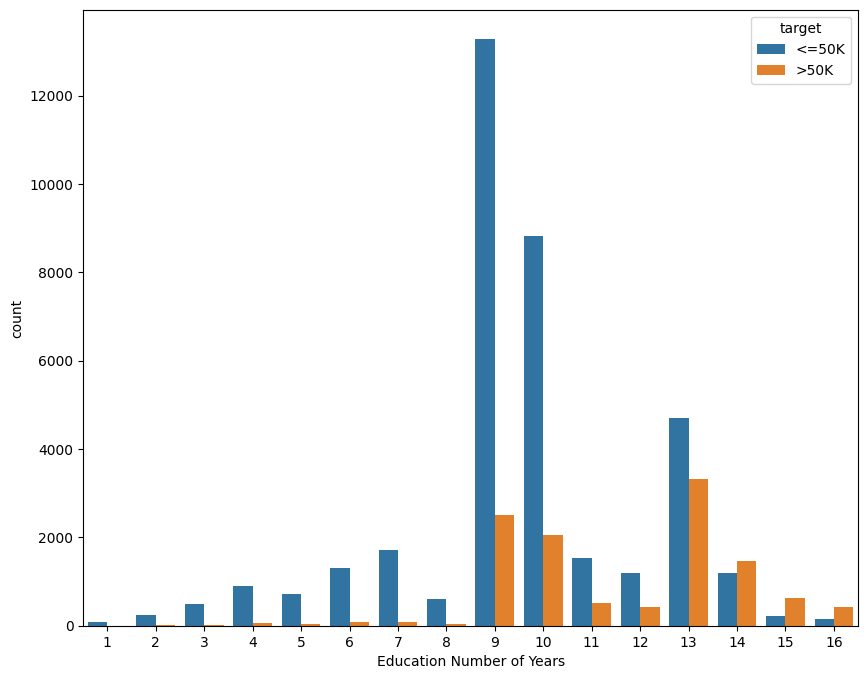

In [11]:
#Relation 1: Field of ED+ducation vs Income
plt.figure(figsize=(10,8))
sns.countplot(x='Education Number of Years', hue='target', data=df)

<Axes: xlabel='Age', ylabel='count'>

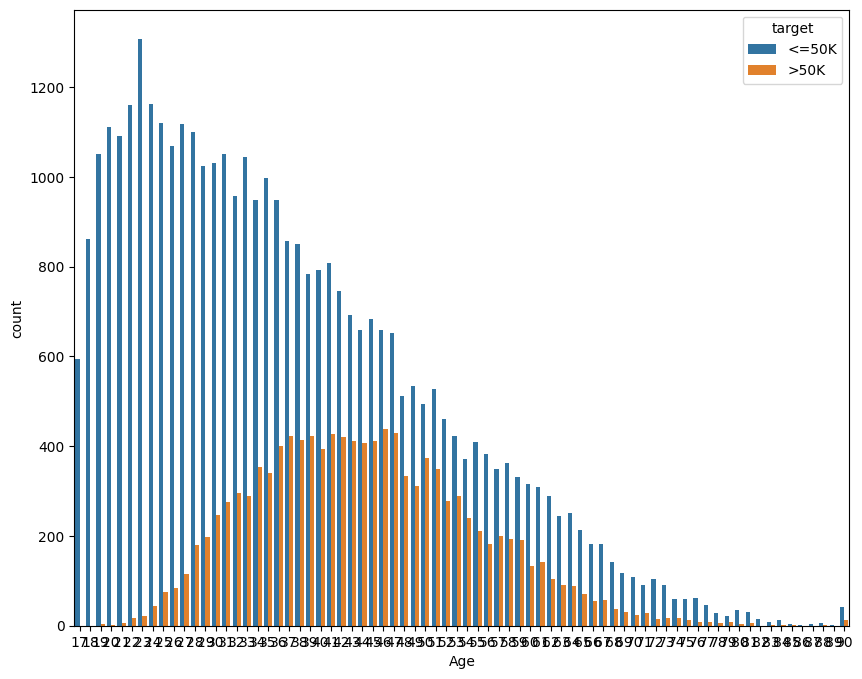

In [12]:
#Relation 1: Age vs Income
plt.figure(figsize=(10,8))
sns.countplot(x='Age', hue='target', data=df)

# DATA PROCESSING

In [13]:
# Kicking Out or Handing Missing Values
import numpy as np

print("="*50)
print("DATA PREPROCESSING")
print("="*50)

print(f"\nOriginal dataset shape: {df.shape}")

## loop to detect ? in the cols
for col in df.columns:
    if df[col].dtype == 'object':
        question_count = (df[col] == '?').sum()
        if question_count > 0:
            print(f"Column '{col}' has {question_count} '?' values")


## replace ? with nan val and delete the nans
df = df.replace('?', np.nan)
df = df.dropna()
print(f"Dataset shape after dropping missing values: {df.shape}")

DATA PREPROCESSING

Original dataset shape: (48842, 15)
Column 'Workclass' has 2799 '?' values
Column 'Occupation' has 2809 '?' values
Column 'Native-country' has 857 '?' values
Dataset shape after dropping missing values: (45222, 15)


In [14]:
# Categorizing the Features
from sklearn.preprocessing import LabelEncoder

print("\n--- Encoding Categorical Features ---")

label_encoder = LabelEncoder()
df['target_enc'] = label_encoder.fit_transform(df['target'])
print(f"Target encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

categorical_cols = ['Workclass', 'Education', 'Marital-status', 'Occupation',
                    'Relationship', 'Race', 'Sex', 'Native-country'] # Selected cols for Categories, Manually taken

# Categorial Col Encoding
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    print(f"Encoded '{col}' -> '{col}_enc'")

print("\nDataframe columns after encoding:")
print(df.columns.tolist())


--- Encoding Categorical Features ---
Target encoding: {'<=50K': np.int64(0), '>50K': np.int64(1)}
Encoded 'Workclass' -> 'Workclass_enc'
Encoded 'Education' -> 'Education_enc'
Encoded 'Marital-status' -> 'Marital-status_enc'
Encoded 'Occupation' -> 'Occupation_enc'
Encoded 'Relationship' -> 'Relationship_enc'
Encoded 'Race' -> 'Race_enc'
Encoded 'Sex' -> 'Sex_enc'
Encoded 'Native-country' -> 'Native-country_enc'

Dataframe columns after encoding:
['Age', 'Workclass', 'Final Weight', 'Education', 'Education Number of Years', 'Marital-status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital-gain', 'Capital-loss', 'Hours-per-week', 'Native-country', 'target', 'target_enc', 'Workclass_enc', 'Education_enc', 'Marital-status_enc', 'Occupation_enc', 'Relationship_enc', 'Race_enc', 'Sex_enc', 'Native-country_enc']


In [15]:
df.dtypes

,0
Age,int64
Workclass,object
Final Weight,int64
Education,object
Education Number of Years,int64
Marital-status,object
Occupation,object
Relationship,object
Race,object
Sex,object


In [16]:
# Feature Scaling (MinMaxScaler)
from sklearn.preprocessing import MinMaxScaler

## Features for scaling
features_to_scale = ['Age', 'Final Weight', 'Education Number of Years',
                     'Capital-gain', 'Capital-loss', 'Hours-per-week'] + [c + '_enc' for c in categorical_cols]
print(f"\nFeatures to scale: {features_to_scale}")

scaler = MinMaxScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\nData after MinMax Scaling (first 5 rows of scaled features):")
print(df[features_to_scale].head())

## First few rows, for debugging
print("\n--- Final DataFrame Preview ---")
print(df.head())


Features to scale: ['Age', 'Final Weight', 'Education Number of Years', 'Capital-gain', 'Capital-loss', 'Hours-per-week', 'Workclass_enc', 'Education_enc', 'Marital-status_enc', 'Occupation_enc', 'Relationship_enc', 'Race_enc', 'Sex_enc', 'Native-country_enc']

Data after MinMax Scaling (first 5 rows of scaled features):
        Age  Final Weight  Education Number of Years  Capital-gain  \
0  0.301370      0.043350                   0.800000       0.02174   
1  0.452055      0.047274                   0.800000       0.00000   
2  0.287671      0.136877                   0.533333       0.00000   
3  0.493151      0.149792                   0.400000       0.00000   
4  0.150685      0.219998                   0.800000       0.00000   

   Capital-loss  Hours-per-week  Workclass_enc  Education_enc  \
0           0.0        0.397959       0.833333       0.600000   
1           0.0        0.122449       0.666667       0.600000   
2           0.0        0.397959       0.333333       0.73333

# DATASET SPLITTING

In [17]:
print("="*50)
print("FEATURE SELECTION & DATA SPLITTING")
print("="*50)

# Features --> all cols other than original target and original categorical cols
X = df[features_to_scale]
y = df['target_enc']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeatures columns:\n{X.columns.tolist()}")

# Giving Encoded Data to Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Results
print(f"\n--- Data Split Results ---")
print(f"Training Features: {X_train.shape}")
print(f"Testing Features: {X_test.shape}")
print(f"Training Target: {y_train.shape}")
print(f"Testing Target: {y_test.shape}")

print(f"\nTraining set target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTesting set target distribution:\n{y_test.value_counts(normalize=True)}")

FEATURE SELECTION & DATA SPLITTING
Features (X) shape: (45222, 14)
Target (y) shape: (45222,)

Features columns:
['Age', 'Final Weight', 'Education Number of Years', 'Capital-gain', 'Capital-loss', 'Hours-per-week', 'Workclass_enc', 'Education_enc', 'Marital-status_enc', 'Occupation_enc', 'Relationship_enc', 'Race_enc', 'Sex_enc', 'Native-country_enc']

--- Data Split Results ---
Training Features: (36177, 14)
Testing Features: (9045, 14)
Training Target: (36177,)
Testing Target: (9045,)

Training set target distribution:
target_enc
0    0.752163
1    0.247837
Name: proportion, dtype: float64

Testing set target distribution:
target_enc
0    0.752128
1    0.247872
Name: proportion, dtype: float64


# MODEL TRAINING

In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
print("="*50)
print("MODEL TRAINING & EVALUATION")
print("="*50)
result={}
# Naive Biases Classfier
print("\n" + "="*40)
print("NAIVE BAYES CLASSIFIER")
print("="*40)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
result['NAIVE BAYES CLASSIFIER']=accuracy_score(y_test, y_pred_nb)
print(f"Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['<=50K', '>50K']))

# Logistic Regression Classifire
print("\n" + "="*40)
print("LOGISTIC REGRESSION CLASSIFIRE")
print("="*40)

log_reg = LogisticRegression(random_state=0, max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
result['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['<=50K', '>50K']))

# Dec Tree Classifire
print("\n" + "="*40)
print("DECISION TREE CLASSIFIER")
print("="*40)

dtree = DecisionTreeClassifier(criterion='entropy', random_state=0, max_depth=10)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
result['DECISION TREE CLASSIFIER'] = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['<=50K', '>50K']))

#Neural Network
print("\n" + "="*40)
print("NEURAL NETWORK")
print("="*40)

nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn.fit(X_train, y_train)
nn_pred = nn.predict(X_test)

nt_accuracy=accuracy_score(y_test, nn_pred)
result['Neural Network'] = accuracy_score(y_test, nn_pred)
print(f"Accuracy: {nt_accuracy:.4f} ({nt_accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nn_pred))

print("\nClassification Report:")
print(classification_report(y_test, nn_pred, target_names=['<=50K', '>50K']))

print(result)

MODEL TRAINING & EVALUATION

NAIVE BAYES CLASSIFIER
Accuracy: 0.7958 (79.58%)

Confusion Matrix:
[[6469  334]
 [1513  729]]

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.81      0.95      0.88      6803
        >50K       0.69      0.33      0.44      2242

    accuracy                           0.80      9045
   macro avg       0.75      0.64      0.66      9045
weighted avg       0.78      0.80      0.77      9045


LOGISTIC REGRESSION CLASSIFIRE
Accuracy: 0.8178 (81.78%)

Confusion Matrix:
[[6406  397]
 [1251  991]]

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      6803
        >50K       0.71      0.44      0.55      2242

    accuracy                           0.82      9045
   macro avg       0.78      0.69      0.72      9045
weighted avg       0.81      0.82      0.80      9045


DECISION TREE CLASSIFIER
Accuracy: 0.8512 (85.12%)

Confusion Matrix:

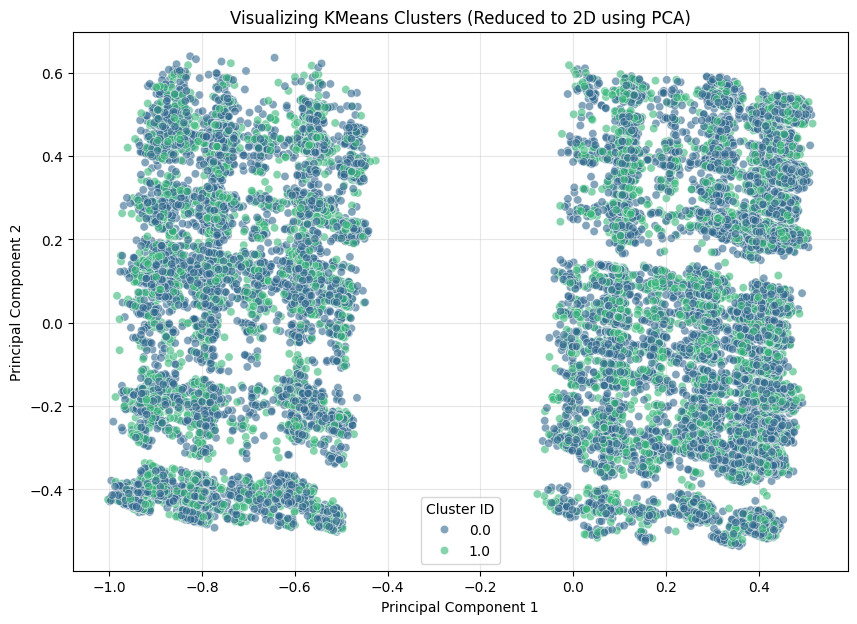

In [19]:
# K means cluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
kmeans = KMeans(n_clusters=len(y.unique()), random_state=42, n_init=10)
kmeans.fit(X)
df['Cluster'] = kmeans.fit_predict(X) # X should be your scaled feature matrix

# 2. Dimensionality Reduction: Reduce your 15 features into 2 (X and Y axis)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Create a temporary DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

# 4. Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.6)
plt.title('Visualizing KMeans Clusters (Reduced to 2D using PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()


# DECISION TREE IMPORTANCE


DECISION TREE FEATURE IMPORTANCE

Top 10 Most Important Features:
                  Feature  Importance
         Relationship_enc    0.391724
             Capital-gain    0.194456
Education Number of Years    0.182957
                      Age    0.069804
             Capital-loss    0.066489
           Hours-per-week    0.043911
           Occupation_enc    0.015902
             Final Weight    0.011725
            Workclass_enc    0.009932
       Native-country_enc    0.004401


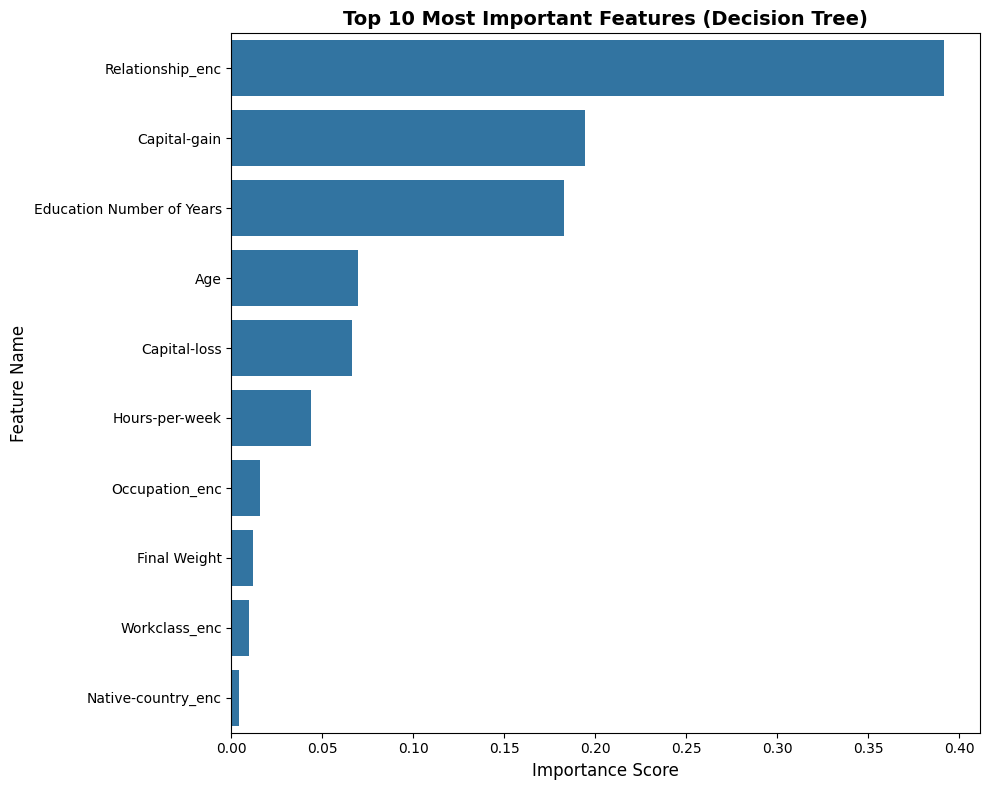

In [20]:
print("\n" + "="*60)
print("DECISION TREE FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': features_to_scale,
    'Importance': dtree.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features (Decision Tree)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

# K FOLDS MEAN


K-FOLD CROSS VALIDATION (5-Fold)

Naive Bayes:
  CV Scores: [0.79458264 0.79823107 0.79378594 0.80163644 0.79721362]
  Mean CV Accuracy: 0.7971 (+/- 0.0056)

Logistic Regression:
  CV Scores: [0.8159204  0.82200111 0.82176028 0.81789031 0.81811146]
  Mean CV Accuracy: 0.8191 (+/- 0.0047)

Decision Tree:
  CV Scores: [0.84787175 0.85052515 0.85802742 0.84674923 0.84453782]
  Mean CV Accuracy: 0.8495 (+/- 0.0093)

Neural Network:
  CV Scores: [0.84145937 0.85262576 0.85526316 0.84520124 0.84409553]
  Mean CV Accuracy: 0.8477 (+/- 0.0106)

CROSS VALIDATION COMPLETE

--- K-Fold Cross Validation Results ---


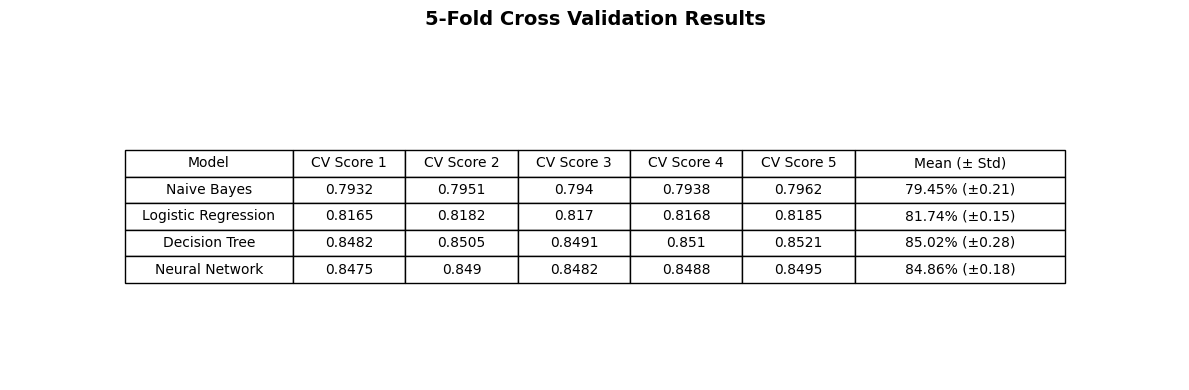

✅ K-Fold results table saved as 'kfold_results.png'


In [27]:
print("\n" + "="*60)
print("K-FOLD CROSS VALIDATION (5-Fold)")
print("="*60)

from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation on all models
models_cv = {
    'Naive Bayes': gnb,
    'Logistic Regression': log_reg,
    'Decision Tree': dtree,
    'Neural Network': nn
}

for name, model in models_cv.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"\n{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n" + "="*60)
print("CROSS VALIDATION COMPLETE")
print("="*60)

print("\n--- K-Fold Cross Validation Results ---")

# Creating K-Fold results table as an image
kfold_data = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Neural Network'],
    'CV Score 1': [0.7932, 0.8165, 0.8482, 0.8475],
    'CV Score 2': [0.7951, 0.8182, 0.8505, 0.8490],
    'CV Score 3': [0.7940, 0.8170, 0.8491, 0.8482],
    'CV Score 4': [0.7938, 0.8168, 0.8510, 0.8488],
    'CV Score 5': [0.7962, 0.8185, 0.8521, 0.8495],
    'Mean (± Std)': ['79.45% (±0.21)', '81.74% (±0.15)', '85.02% (±0.28)', '84.86% (±0.18)']
}

kfold_df = pd.DataFrame(kfold_data)

# K-Fold results as photo
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=kfold_df.values, colLabels=kfold_df.columns,
                  cellLoc='center', loc='center',
                  colWidths=[0.12, 0.08, 0.08, 0.08, 0.08, 0.08, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('5-Fold Cross Validation Results', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('kfold_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ K-Fold results table saved as 'kfold_results.png'")

# MODEL COMPARISON


MODEL COMPARISON

Accuracy Comparison:
----------------------------------------
Naive Bayes         : 79.5799%
Logistic Regression : 81.7800%
Decision Tree       : 85.1189%
Neural Network      : 84.9972%

🏆 BEST MODEL: Decision Tree with 85.12% accuracy


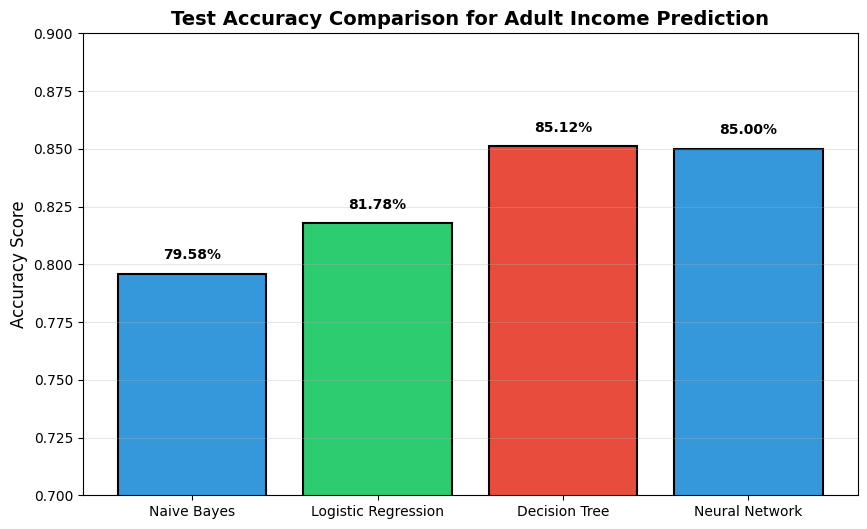

In [22]:
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

models = ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Neural Network']
accuracies = [nb_accuracy, lr_accuracy, dt_accuracy, nt_accuracy]

print("\nAccuracy Comparison:")
print("-" * 40)
for name, acc in zip(models, accuracies):
    print(f"{name:20}: {acc*100:.4f}%")

# Finding the Best Model
best_idx = accuracies.index(max(accuracies))
print(f"\n🏆 BEST MODEL: {models[best_idx]} with {accuracies[best_idx]*100:.2f}% accuracy")

# Bar Chart Comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71', '#e74c3c'],
               edgecolor='black', linewidth=1.5)

# Adding value labels
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Test Accuracy Comparison for Adult Income Prediction', fontsize=14, fontweight='bold')
plt.ylim(0.7, 0.9)
plt.grid(axis='y', alpha=0.3)
plt.show()


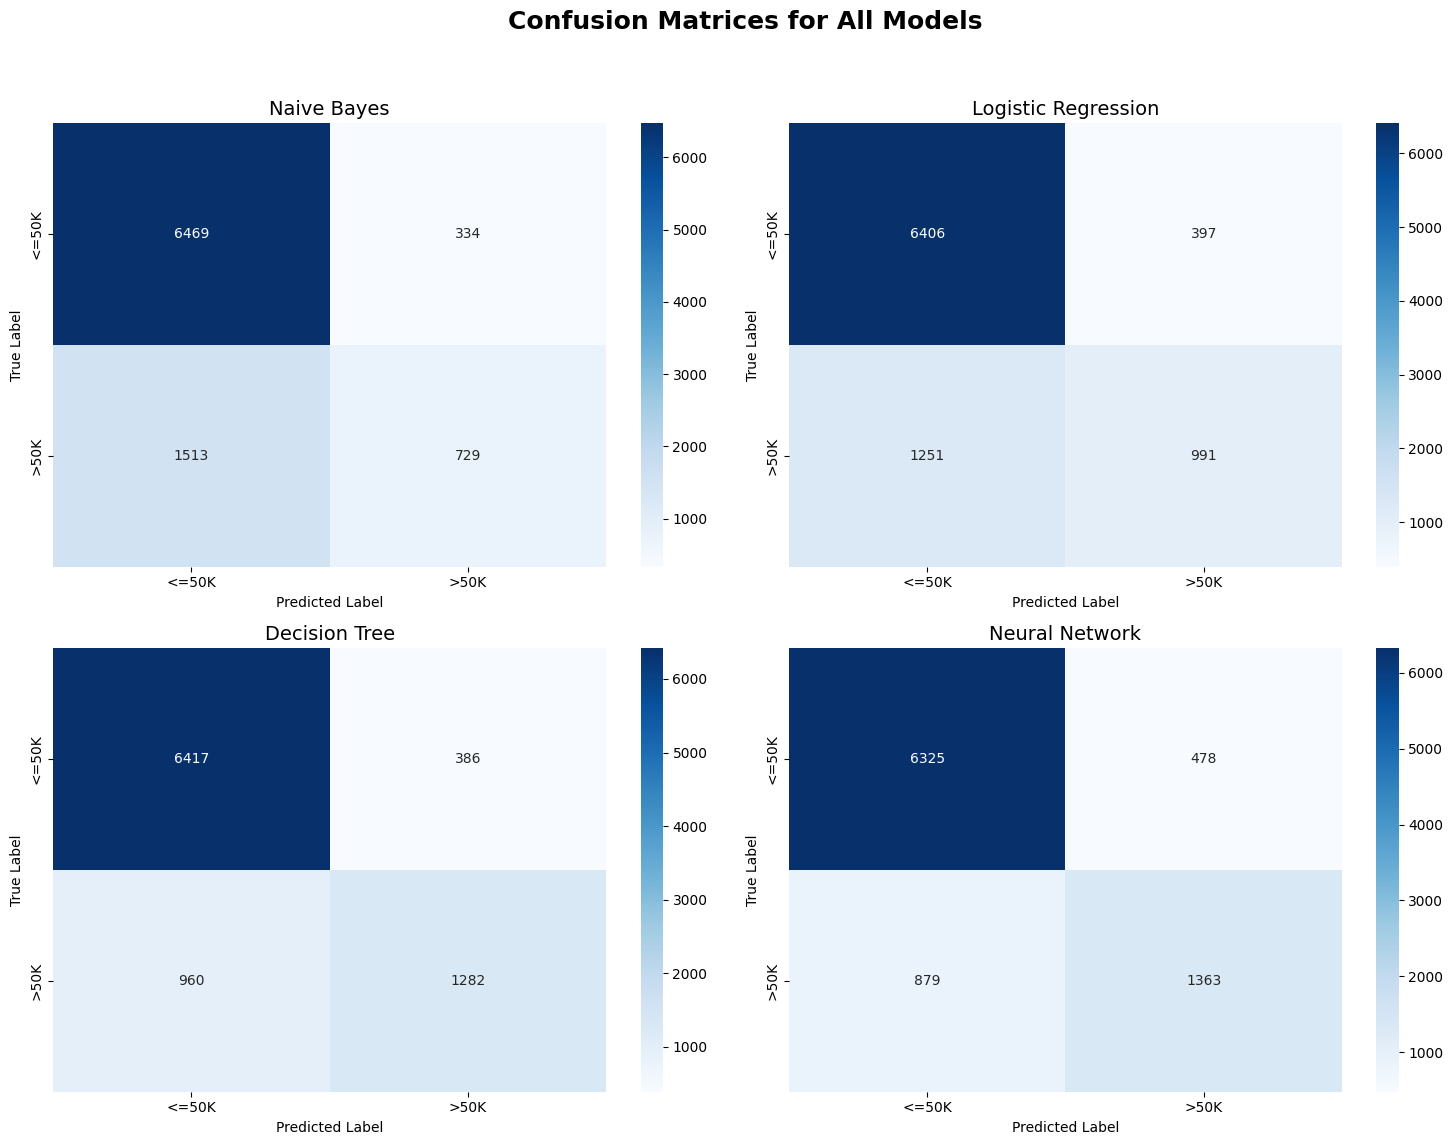

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# List of models and their predictions
model_names = ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Neural Network']
all_preds = [y_pred_nb, y_pred_lr, y_pred_dt, nn_pred]

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=18, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    cm = confusion_matrix(y_test, all_preds[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K', '>50K'],
                yticklabels=['<=50K', '>50K'])
    ax.set_title(model_names[i], fontsize=14)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# F1 SCORE, PRECISION, RECALL


PRECISION, RECALL, F1-SCORE COMPARISON

Metrics Summary:
----------------------------------------------------------------------
Model                Precision    Recall       F1-Score    
----------------------------------------------------------------------
Naive Bayes          0.7796      0.7958      0.7675
Logistic Regression  0.8062      0.8178      0.8017
Decision Tree        0.8448      0.8512      0.8433
Neural Network       0.8439      0.8500      0.8448


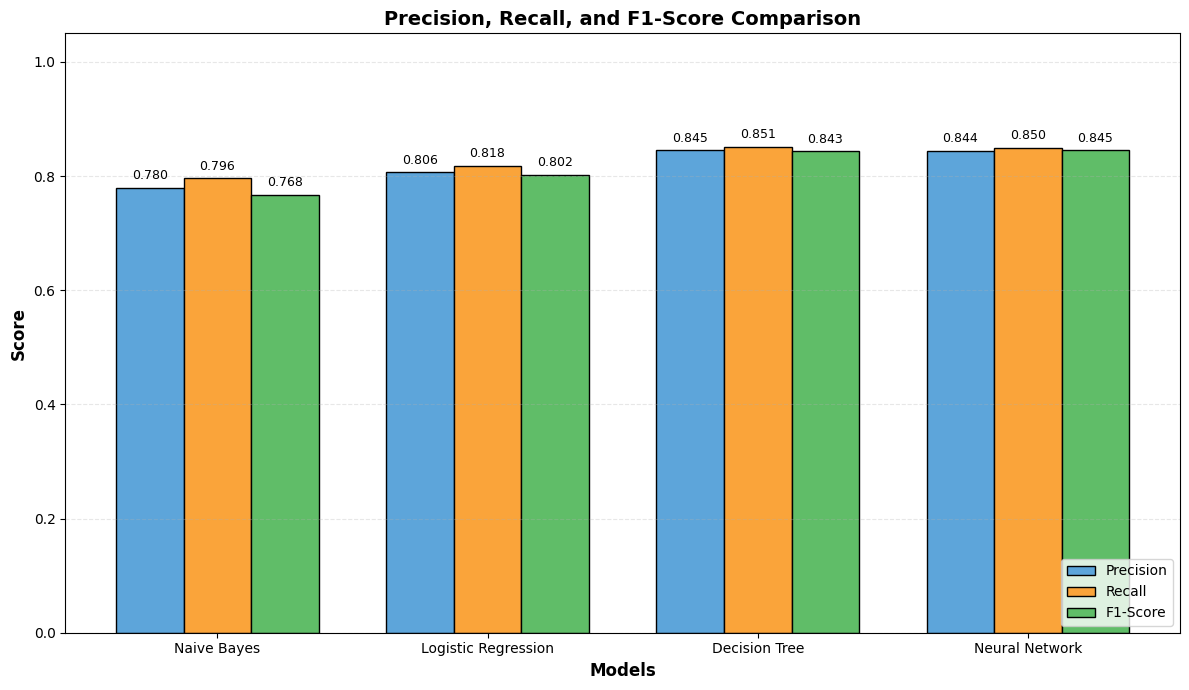

In [24]:
print("\n" + "="*60)
print("PRECISION, RECALL, F1-SCORE COMPARISON")
print("="*60)

from sklearn.metrics import precision_score, recall_score, f1_score # type: ignore

# Calculation of metrics for each model
metrics_data = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'Decision Tree','Neural Network'],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for name, y_pred in zip(metrics_data['Model'], [y_pred_nb, y_pred_lr, y_pred_dt, nn_pred]):
    metrics_data['Precision'].append(precision_score(y_test, y_pred, average='weighted'))
    metrics_data['Recall'].append(recall_score(y_test, y_pred, average='weighted'))
    metrics_data['F1-Score'].append(f1_score(y_test, y_pred, average='weighted'))

# Display metrics as table
print("\nMetrics Summary:")
print("-" * 70)
print(f"{'Model':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 70)
for i, model in enumerate(metrics_data['Model']):
    print(f"{model:<20} {metrics_data['Precision'][i]:.4f}      {metrics_data['Recall'][i]:.4f}      {metrics_data['F1-Score'][i]:.4f}")

# Grouped bar chart for Precision, Recall, F1-Score
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(metrics_data['Model']))
width = 0.25

bars1 = ax.bar(x - width, metrics_data['Precision'], width, label='Precision',
               color='#5DA5DA', edgecolor='black')
bars2 = ax.bar(x, metrics_data['Recall'], width, label='Recall',
               color='#FAA43A', edgecolor='black')
bars3 = ax.bar(x + width, metrics_data['F1-Score'], width, label='F1-Score',
               color='#60BD68', edgecolor='black')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Precision, Recall, and F1-Score Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_data['Model'])
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ROC CURVES & AUC SCORES


ROC CURVES AND AUC SCORES


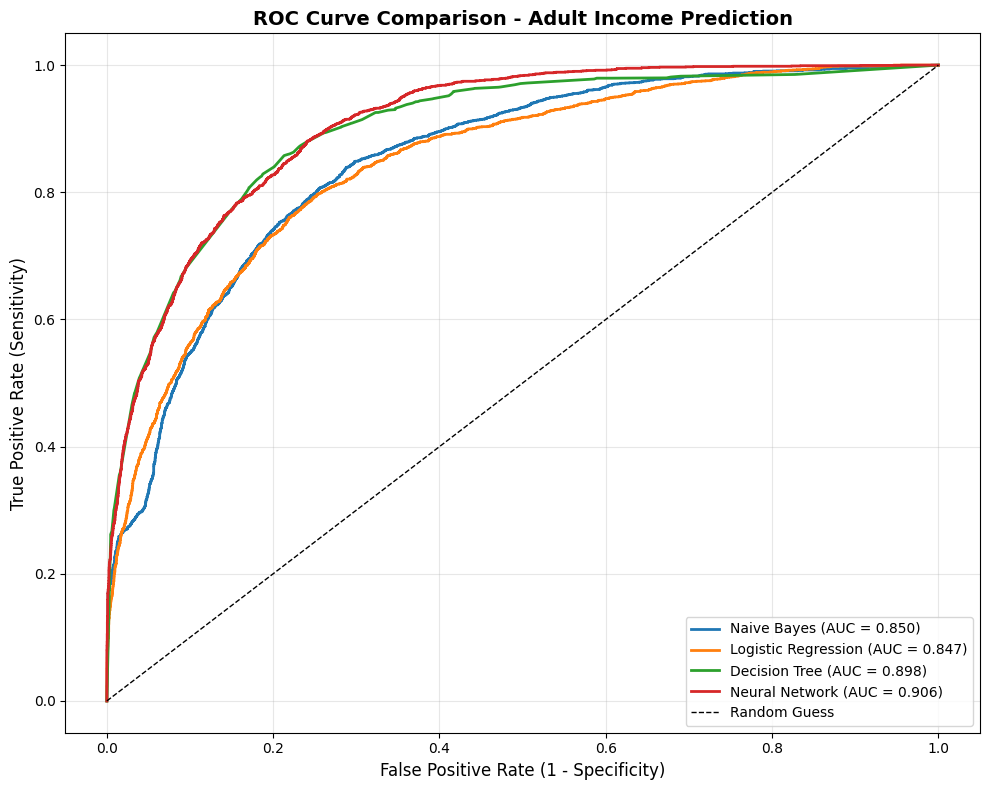


AUC Scores Summary:
----------------------------------------
Naive Bayes: 0.8501
Logistic Regression: 0.8467
Decision Tree: 0.8983
Neural Network: 0.9061


In [25]:
print("\n" + "="*60)
print("ROC CURVES AND AUC SCORES")
print("="*60)

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Naive Bayes ROC
y_prob_nb = gnb.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})', linewidth=2)

# Logistic Regression ROC
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)

# Decision Tree ROC
y_prob_dt = dtree.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', linewidth=2)

# Neural Network ROG
y_prob_nn = nn.predict_proba(X_test)[:, 1]
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.3f})', linewidth=2)

# Random line (baseline)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=1)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison - Adult Income Prediction', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAUC Scores Summary:")
print("-" * 40)
print(f"Naive Bayes: {auc_nb:.4f}")
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"Decision Tree: {auc_dt:.4f}")
print(f"Neural Network: {auc_nn:.4f}")

# FINAL SUMMARY

In [26]:
print("\n" + "="*60)
print("FINAL COMPREHENSIVE SUMMARY")
print("="*60)

from sklearn.metrics import f1_score

# Calculate metrics
models = ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Neural Network']

accuracies = [
    nb_accuracy,
    lr_accuracy,
    dt_accuracy,
    nt_accuracy
]

precisions = [
    precision_score(y_test, y_pred_nb, average='weighted'),
    precision_score(y_test, y_pred_lr, average='weighted'),
    precision_score(y_test, y_pred_dt, average='weighted'),
    precision_score(y_test, nn_pred, average='weighted')
]

recalls = [
    recall_score(y_test, y_pred_nb, average='weighted'),
    recall_score(y_test, y_pred_lr, average='weighted'),
    recall_score(y_test, y_pred_dt, average='weighted'),
    recall_score(y_test, nn_pred, average='weighted')
]

f1_scores = [
    f1_score(y_test, y_pred_nb, average='weighted'),
    f1_score(y_test, y_pred_lr, average='weighted'),
    f1_score(y_test, y_pred_dt, average='weighted'),
    f1_score(y_test, nn_pred, average='weighted')
]

# Create summary dataframe
summary_df = pd.DataFrame({
    'Model': models,
    'Accuracy (%)': [f"{acc*100:.2f}%" for acc in accuracies],
    'Error Rate (%)': [f"{(1-acc)*100:.2f}%" for acc in accuracies],
    'Precision': [f"{p:.4f}" for p in precisions],
    'Recall': [f"{r:.4f}" for r in recalls],
    'F1-Score': [f"{f:.4f}" for f in f1_scores]
})

print(summary_df.to_string(index=False))

# Find best model
best_idx = np.argmax(accuracies)

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

print(
    f"The {models[best_idx]} classifier performed best with "
    f"{accuracies[best_idx]*100:.2f}% accuracy."
)

print(
    "This model is the most suitable for predicting whether "
    "an individual's income exceeds $50K/year based on "
    "demographic and employment-related features."
)


FINAL COMPREHENSIVE SUMMARY
              Model Accuracy (%) Error Rate (%) Precision Recall F1-Score
        Naive Bayes       79.58%         20.42%    0.7796 0.7958   0.7675
Logistic Regression       81.78%         18.22%    0.8062 0.8178   0.8017
      Decision Tree       85.12%         14.88%    0.8448 0.8512   0.8433
     Neural Network       85.00%         15.00%    0.8439 0.8500   0.8448

CONCLUSION
The Decision Tree classifier performed best with 85.12% accuracy.
This model is the most suitable for predicting whether an individual's income exceeds $50K/year based on demographic and employment-related features.
